In [2]:
import pandas as pd


In [3]:
df=pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df["age"].describe()

count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

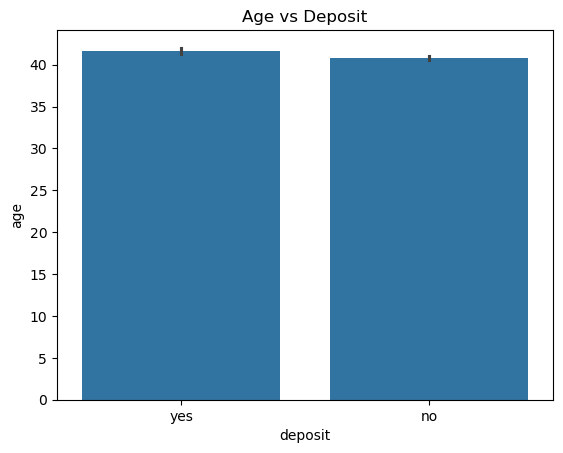

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="deposit", y="age", data=df)
plt.title("Age vs Deposit")
plt.show()

In [6]:
df.groupby(["age", "deposit"]).size().reset_index(name="count")

,age,deposit,count
0,18,no,1
1,18,yes,7
2,19,no,2
3,19,yes,11
4,20,no,5
...,...,...,...
139,89,no,1
140,90,yes,2
141,92,yes,2
142,93,yes,2


In [7]:
pivot = df.pivot_table(
    index="age",
    columns="deposit",
    aggfunc="size",
    fill_value=0
)

pivot

deposit,no,yes
age,,
18,1,7
19,2,11
20,5,15
21,8,22
22,8,40
...,...,...
89,1,0
90,0,2
92,0,2


In [8]:
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_percent

deposit,no,yes
age,,
18,12.500000,87.500000
19,15.384615,84.615385
20,25.000000,75.000000
21,26.666667,73.333333
22,16.666667,83.333333
...,...,...
89,100.000000,0.000000
90,0.000000,100.000000
92,0.000000,100.000000


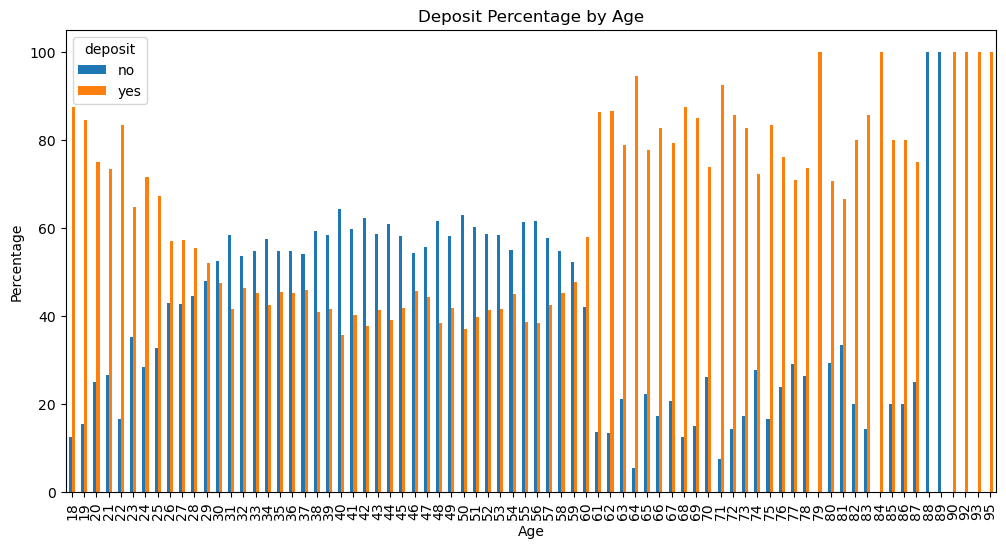

In [9]:
pivot_percent.plot(kind="bar", figsize=(12,6))
plt.title("Deposit Percentage by Age")
plt.xlabel("Age")
plt.ylabel("Percentage")
plt.show()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [13]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

In [16]:
grouped = df.groupby(["job", "age_group", "deposit"]).size().reset_index(name="count")
grouped

C:\Users\Ayuse\AppData\Local\Temp\ipykernel_26264\3266788502.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["job", "age_group", "deposit"]).size().reset_index(name="count")


,job,age_group,deposit,count
0,admin.,18-30,no,126
1,admin.,18-30,yes,143
2,admin.,30-40,no,296
3,admin.,30-40,yes,230
4,admin.,40-50,no,179
...,...,...,...,...
115,unknown,40-50,yes,10
116,unknown,50-60,no,10
117,unknown,50-60,yes,11
118,unknown,60+,no,2


In [19]:
pivot = grouped.pivot_table(
    index=["job", "age_group"],
    columns="deposit",
    values="count",
    fill_value=0,
    observed=False
)

In [20]:
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_percent

deposit                          no         yes
job           age_group                        
admin.        18-30       46.840149   53.159851
              30-40       56.273764   43.726236
              40-50       54.242424   45.757576
              50-60       51.020408   48.979592
              60+         15.384615   84.615385
blue-collar   18-30       54.154728   45.845272
              30-40       65.834428   34.165572
              40-50       65.693431   34.306569
              50-60       66.666667   33.333333
              60+         20.000000   80.000000
entrepreneur  18-30       36.842105   63.157895
              30-40       65.116279   34.883721
              40-50       65.094340   34.905660
              50-60       66.666667   33.333333
              60+         12.500000   87.500000
housemaid     18-30       38.461538   61.538462
              30-40       67.605634   32.394366
              40-50       65.333333   34.666667
              50-60       65.168539   34.831461
              60+         19.230769   80.769231
management    18-30       39.378238   60.621762
              30-40       50.934996   49.065004
              40-50       51.724138   48.275862
              50-60       55.529412   44.470588
              60+          9.615385   90.384615
retired       18-30             NaN         NaN
              30-40       85.714286   14.285714
              40-50       66.666667   33.333333
              50-60       54.237288   45.762712
              60+         18.655098   81.344902
self-employed 18-30       39.534884   60.465116
              30-40       54.248366   45.751634
              40-50       64.835165   35.164835
              50-60       71.428571   28.571429
              60+         10.526316   89.473684
services      18-30       53.535354   46.464646
              30-40       60.880196   39.119804
              40-50       64.215686   35.784314
              50-60       60.360360   39.639640
              60+        100.000000    0.000000
student       18-30       23.232323   76.767677
              30-40       37.254902   62.745098
              40-50       50.000000   50.000000
              50-60             NaN         NaN
              60+               NaN         NaN
technician    18-30       46.687697   53.312303
              30-40       55.785627   44.214373
              40-50       60.381862   39.618138
              50-60       47.826087   52.173913
              60+         23.076923   76.923077
unemployed    18-30       37.931034   62.068966
              30-40       43.650794   56.349206
              40-50       50.000000   50.000000
              50-60       40.277778   59.722222
              60+          0.000000  100.000000
unknown       18-30       42.857143   57.142857
              30-40       45.454545   54.545455
              40-50       61.538462   38.461538
              50-60       47.619048   52.380952
              60+         40.000000   60.000000

In [21]:
pivot_percent = pivot_percent.reset_index()

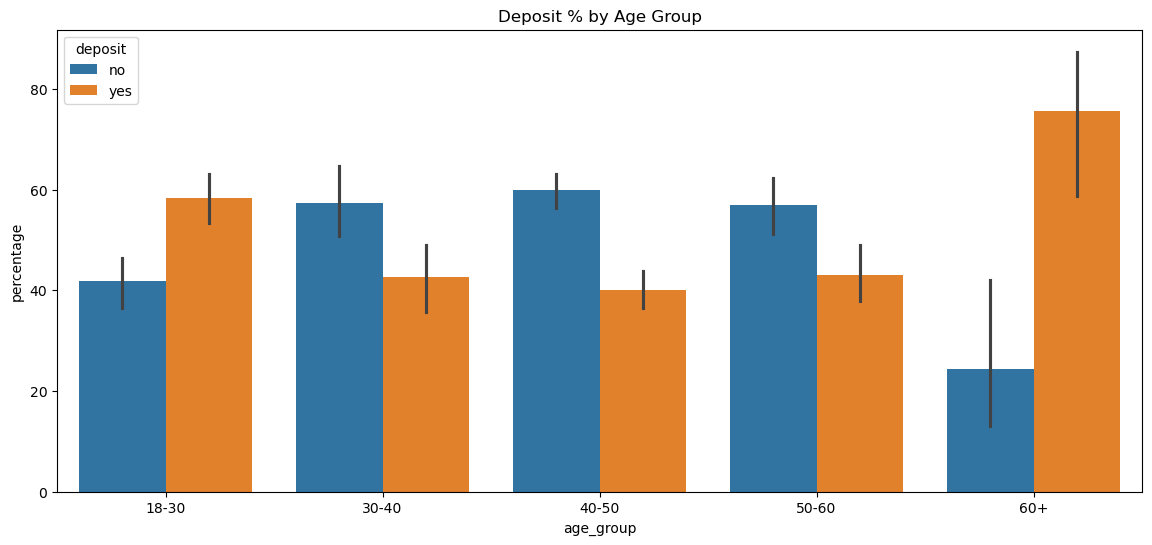

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to long format
plot_data = pivot_percent.melt(
    id_vars=["job", "age_group"],
    var_name="deposit",
    value_name="percentage"
)

plt.figure(figsize=(14,6))

sns.barplot(
    x="age_group",
    y="percentage",
    hue="deposit",
    data=plot_data
)

plt.title("Deposit % by Age Group")
plt.show()

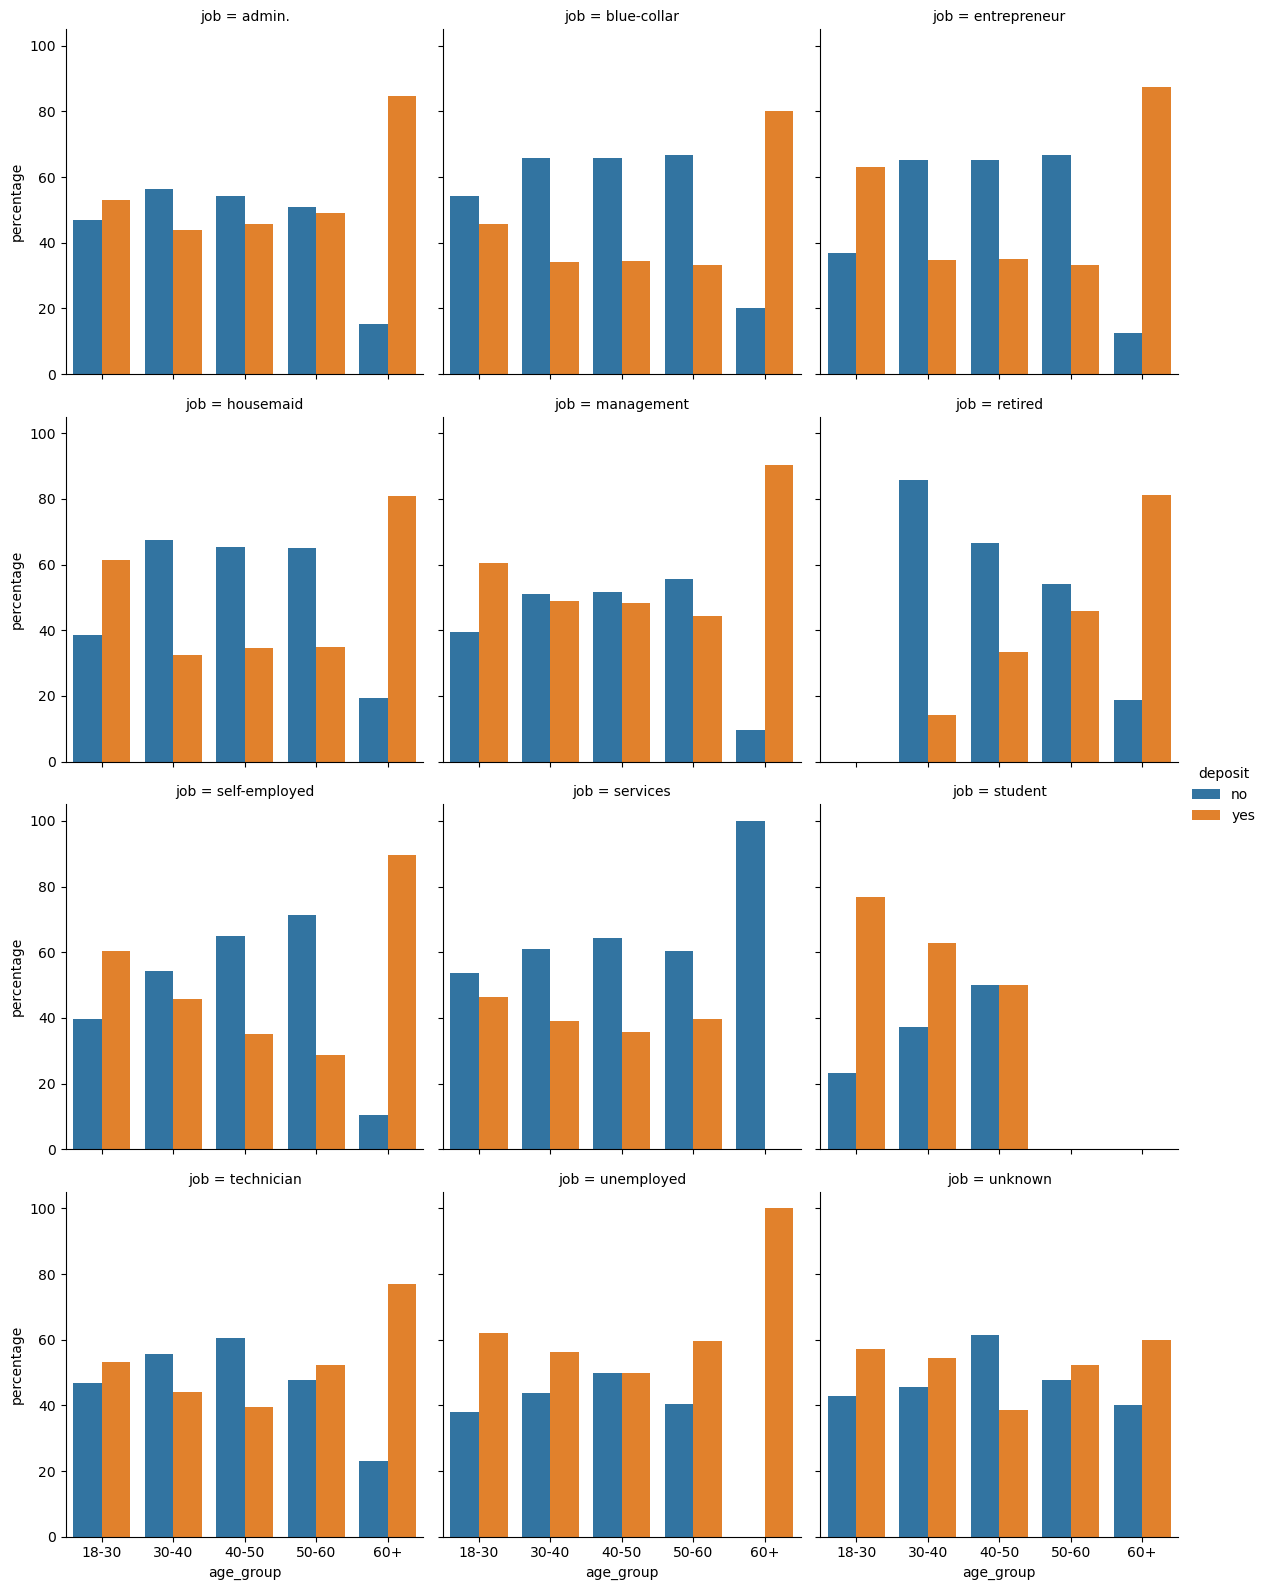

In [23]:
sns.catplot(
    x="age_group",
    y="percentage",
    hue="deposit",
    col="job",
    data=plot_data,
    kind="bar",
    col_wrap=3,
    height=4
)

In [37]:
filtered = df[(df["age"] > 30) & (df["age"] < 60)]


In [38]:
grouped = filtered.groupby(["job", "deposit"]).size().reset_index(name="count")

In [39]:
pivot = grouped.pivot_table(
    index="job",
    columns="deposit",
    values="count",
    fill_value=0
)

In [40]:
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_percent

deposit,no,yes
job,,
admin.,55.038760,44.961240
blue-collar,66.048593,33.951407
entrepreneur,65.217391,34.782609
housemaid,65.789474,34.210526
management,52.351544,47.648456
retired,57.936508,42.063492
self-employed,60.677966,39.322034
services,61.891516,38.108484
student,38.181818,61.818182


In [43]:
result = pivot_percent[pivot_percent["yes"] > 50]
result


deposit,no,yes
job,,
student,38.181818,61.818182
unemployed,45.392491,54.607509
